## COLOR CODE DEMO

This is a demo to use Gemma 4 as a color picker, and visualize the output. 

The color picker is a average picking rather than point based color picking. 

What's more, through attention analysis, you can check which part is used for color picking. 

In [1]:
%%capture
!pip install -U transformers

In [2]:
import io
import math

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

In [3]:
MODEL_PATH = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-12b-it/2"

# Load model
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

## Prepare Input

In [4]:
# Prompt
image = "http://places2.csail.mit.edu/imgs/IMG_6276.jpeg"
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {
        "role": "user", "content": 
         [
            {"type": "image", "url": image},
            {"type": "text", "text": "Analyse the color code (HEX code) of the seats in the image."},
         ],
    },
]


# Process input
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=False
)
print(f"Streamed Text: {text}")
inputs = processor(text=text, images=image, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

Streamed Text: <bos><|turn>system
You are a helpful assistant.<turn|>
<|turn>user
<|image|>Analyse the color code (HEX code) of the seats in the image.<turn|>
<|turn>model
<|channel>thought
<channel|>


In [5]:
# Generate output
# Generate output
outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
analysis_input_ids = outputs
analysis_attention_mask = torch.ones_like(analysis_input_ids, device=analysis_input_ids.device)
last_n_tokens_to_show = 256
# Parse thinking
processor.parse_response(response)

{'content': 'I did not find any bounding box detections for seats.',
 'role': 'assistant'}

## Show Color Picking Results

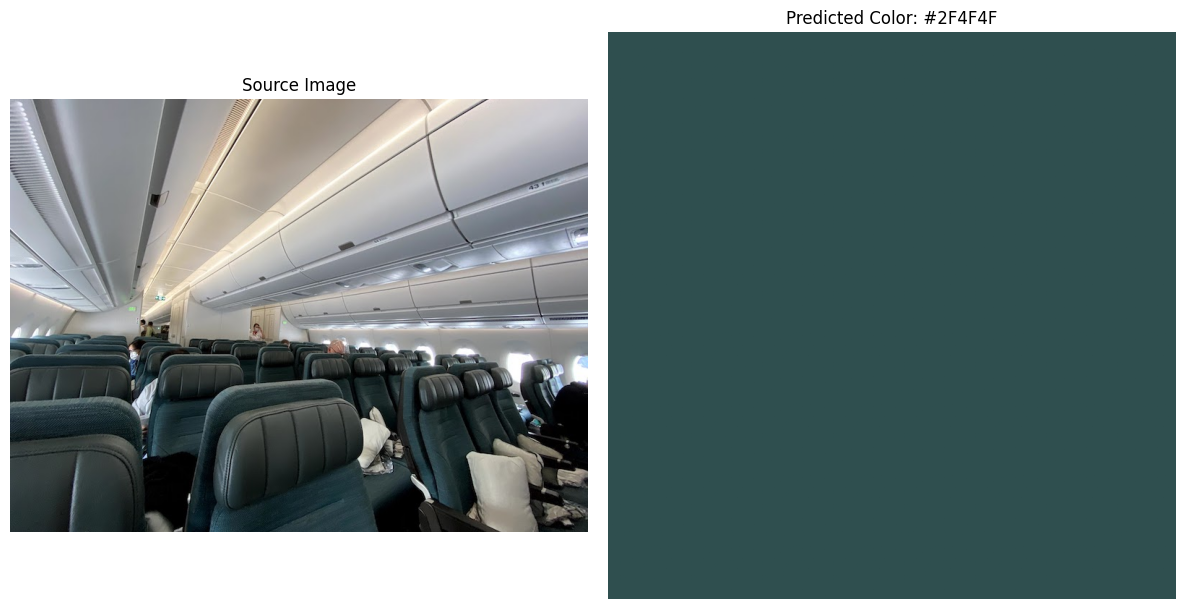

In [6]:
# Get color code through text input 
# predicted_color_code = input("Input the color code that LLM predict, I will plot it: ")
predicted_color_code = "#2F4F4F"

if str(image).startswith(("http://", "https://")):
    image_response = requests.get(image, timeout=30)
    image_response.raise_for_status()
    img_1 = Image.open(io.BytesIO(image_response.content)).convert("RGB")
else:
    img_1 = Image.open(image).convert("RGB")


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_1)
axes[0].set_title("Source Image")
axes[0].axis("off")


color_patch = np.ones((200, 200, 3), dtype=np.float32)
color_patch[:] = np.array(Image.new("RGB", (1, 1), predicted_color_code))[0, 0] / 255.0
axes[1].imshow(color_patch)
axes[1].set_title(f"Predicted Color: {predicted_color_code}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:

def _load_image(image_source):
    if isinstance(image_source, Image.Image):
        return image_source.convert("RGB")

    if str(image_source).startswith(("http://", "https://")):
        image_bytes = requests.get(image_source, timeout=30)
        image_bytes.raise_for_status()
        return Image.open(io.BytesIO(image_bytes.content)).convert("RGB")

    return Image.open(image_source).convert("RGB")


def _find_image_token_positions(input_ids, tokenizer, return_debug=False):
    candidate_tokens = (
        "<|image|>",
        "<image_soft_token>",
        "<start_of_image>",
        "<end_of_image>",
        "<image>",
    )
    candidate_entries = []
    candidate_ids = set()
    unk_token_id = getattr(tokenizer, "unk_token_id", None)

    def _register_candidate(token, source):
        token_id = tokenizer.convert_tokens_to_ids(token)
        is_valid = token_id is not None and token_id != unk_token_id
        if is_valid:
            candidate_ids.add(token_id)
        candidate_entries.append(
            {
                "source": source,
                "token": token,
                "token_id": token_id,
                "is_valid": is_valid,
            }
        )

    for token in candidate_tokens:
        _register_candidate(token, "builtin")

    for token in getattr(tokenizer, "additional_special_tokens", []) or []:
        if "image" not in str(token).lower():
            continue
        _register_candidate(token, "additional_special_tokens")

    input_id_list = input_ids.tolist()
    positions = [
        idx
        for idx, token_id in enumerate(input_id_list)
        if token_id in candidate_ids
    ]

    try:
        token_strings = tokenizer.convert_ids_to_tokens(input_id_list)
    except Exception:
        token_strings = [str(token_id) for token_id in input_id_list]

    text_based_positions = [
        idx
        for idx, token in enumerate(token_strings)
        if "image" in str(token).lower()
    ]

    debug_info = {
        "candidate_entries": candidate_entries,
        "candidate_ids": sorted(candidate_ids),
        "text_based_positions": text_based_positions,
        "token_strings": token_strings,
        "special_tokens_map": getattr(tokenizer, "special_tokens_map", {}),
    }

    if return_debug:
        return positions, debug_info
    return positions


def _normalize_attention_map(attention_map):
    attention_map = attention_map.astype(np.float32)
    attention_map -= attention_map.min()
    max_value = attention_map.max()
    if max_value > 0:
        attention_map /= max_value
    return attention_map


def _preview_token_windows(token_strings, positions, radius=2, max_windows=8):
    windows = []
    for pos in positions[:max_windows]:
        start = max(pos - radius, 0)
        end = min(pos + radius + 1, len(token_strings))
        window = " | ".join(
            f"{idx}:{token_strings[idx]}"
            for idx in range(start, end)
        )
        windows.append(window)
    return windows


## Analyse the attention

In [8]:
with torch.no_grad():
    attention_inputs = {
        key: value
        for key, value in inputs.items()
        if key not in {"input_ids", "attention_mask"}
    }
    attention_outputs = model(
        **attention_inputs,
        input_ids=analysis_input_ids,
        attention_mask=analysis_attention_mask,
        output_attentions=True,
        return_dict=True,
    )

all_attentions = attention_outputs.attentions or ()
valid_attentions = [layer for layer in all_attentions if layer is not None]
if not valid_attentions:
    raise RuntimeError(
        "Model did not return attentions. Reload the model with "
        "attn_implementation='eager' before requesting output_attentions=True."
    )

last_layers = valid_attentions[-4:] if len(valid_attentions) >= 4 else valid_attentions
avg_attention = torch.stack(
    [layer[0].float().mean(dim=0).cpu() for layer in last_layers]
).mean(dim=0)

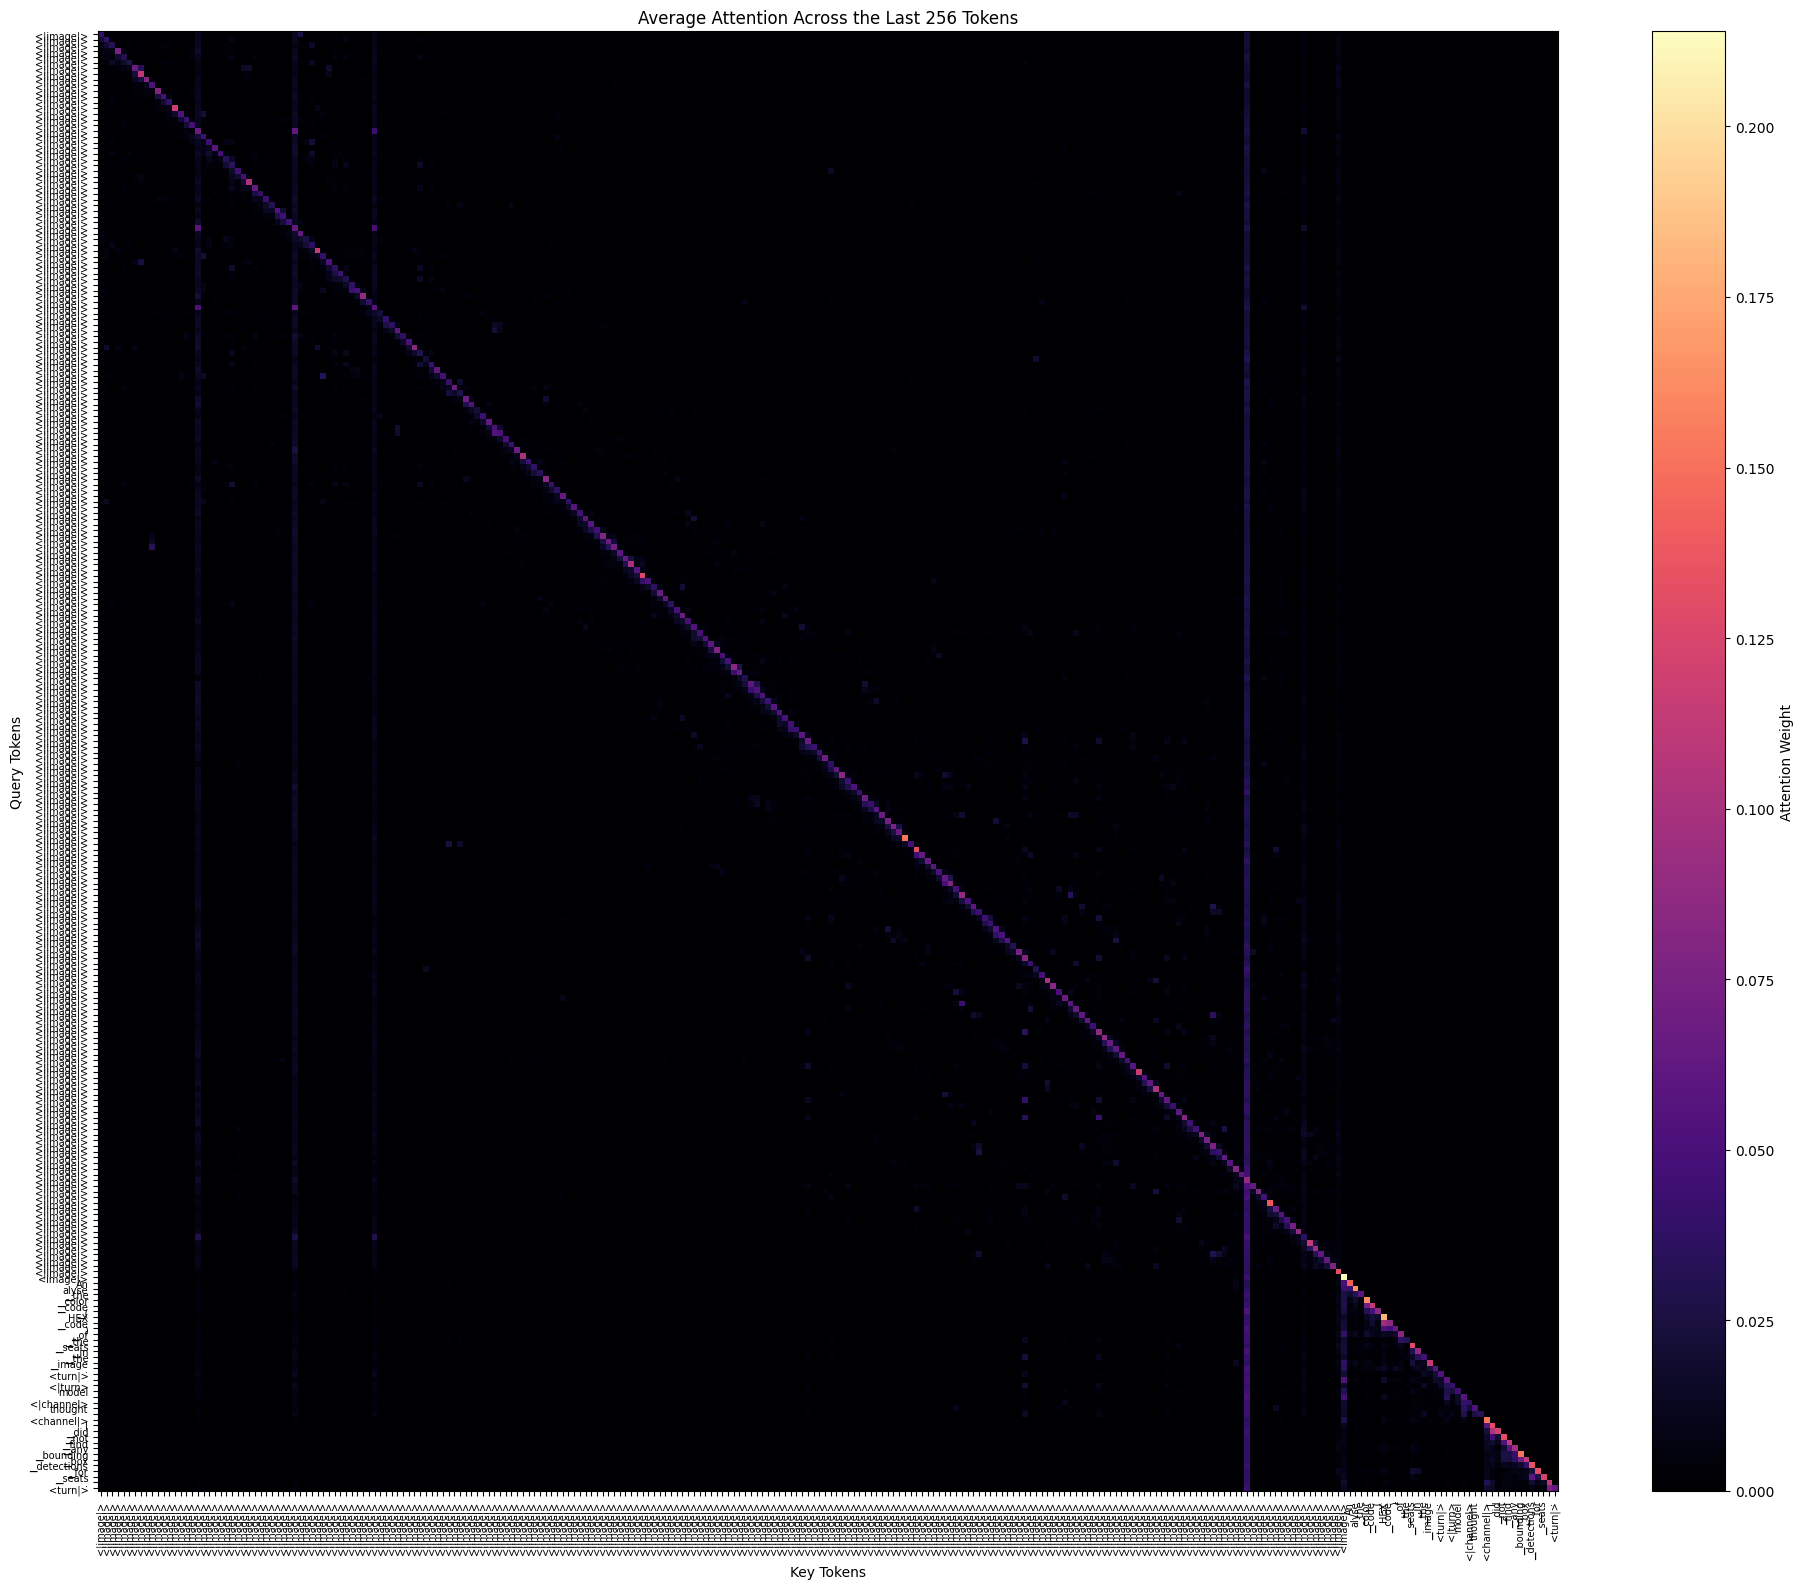

In [9]:
# Visualize the last n tokens from the full prompt + response sequence.
max_tokens_to_show = min(last_n_tokens_to_show, avg_attention.shape[0])
token_start = avg_attention.shape[0] - max_tokens_to_show
display_attention = avg_attention[token_start:, token_start:].numpy()
token_labels = processor.tokenizer.convert_ids_to_tokens(
    analysis_input_ids[0, token_start:].detach().cpu().tolist()
)

plt.figure(figsize=(20, 16))
plt.imshow(display_attention, cmap="magma")
plt.title(f"Average Attention Across the Last {max_tokens_to_show} Tokens")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.xticks(range(max_tokens_to_show), token_labels, rotation=90, fontsize=7)
plt.yticks(range(max_tokens_to_show), token_labels, fontsize=7)
plt.colorbar(label="Attention Weight")
plt.tight_layout()
plt.show()

## Analyse the attention on image

Token diagnostics: {'prompt_tokens': 308, 'full_sequence_tokens': 320, 'generated_tokens': 12, 'prefix_matches_prompt': True, 'matched_image_positions': 266, 'text_based_image_positions': 269}
Image token candidate ids:
  - builtin: <|image|> -> 258880 (valid=True)
  - builtin: <image_soft_token> -> 3 (valid=False)
  - builtin: <start_of_image> -> 3 (valid=False)
  - builtin: <end_of_image> -> 3 (valid=False)
  - builtin: <image> -> 3 (valid=False)
Matched image token positions: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35] ...
Token windows containing the word 'image':
  - 13:user | 14:
 | 15:<|image> | 16:<|image|> | 17:<|image|>
  - 14:
 | 15:<|image> | 16:<|image|> | 17:<|image|> | 18:<|image|>
  - 15:<|image> | 16:<|image|> | 17:<|image|> | 18:<|image|> | 19:<|image|>
  - 16:<|image|> | 17:<|image|> | 18:<|image|> | 19:<|image|> | 20:<|image|>
  - 17:<|image|> | 18:<|image|> | 19:<|image|> | 20:<|image|> | 21:<|image|>
  - 18:<|image|> | 19:<|ima

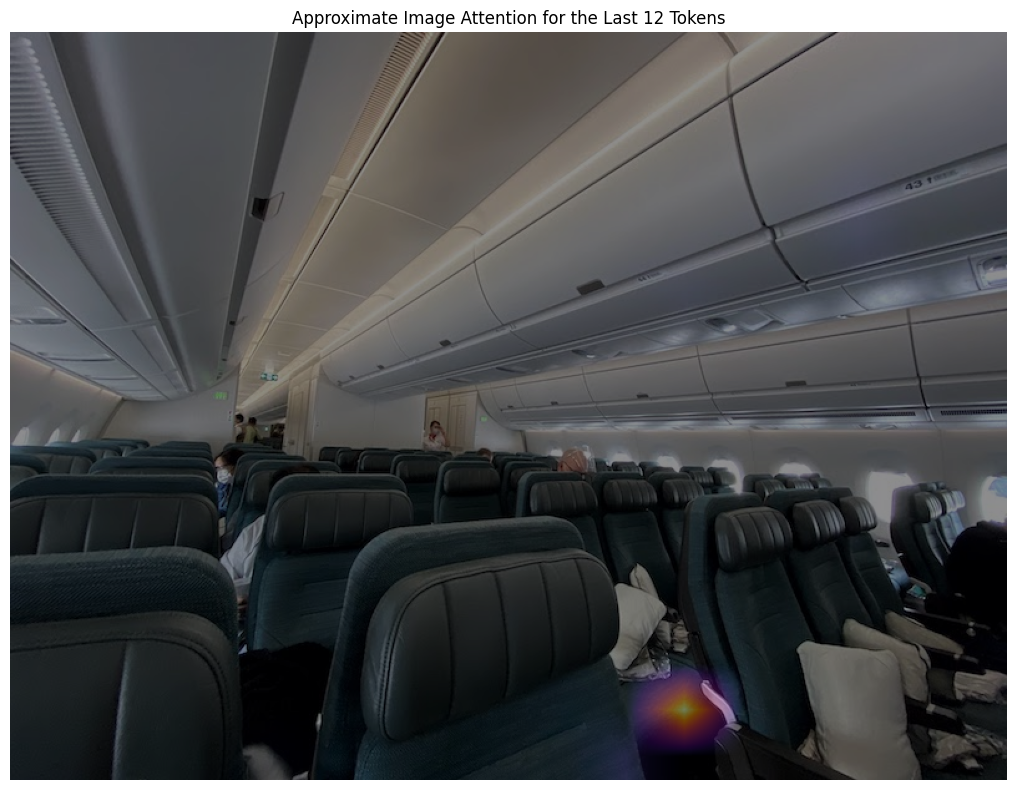

In [10]:

# Visualize the attention map on the image
full_input_ids = analysis_input_ids[0].detach().cpu()
prompt_input_ids = inputs["input_ids"][0].detach().cpu()
image_token_positions, image_token_debug = _find_image_token_positions(
    full_input_ids,
    processor.tokenizer,
    return_debug=True,
)

generated_token_count = max(int(full_input_ids.shape[-1] - prompt_input_ids.shape[-1]), 0)
prefix_matches = bool(
    full_input_ids.shape[-1] >= prompt_input_ids.shape[-1]
    and torch.equal(full_input_ids[: prompt_input_ids.shape[-1]], prompt_input_ids)
)

print(
    "Token diagnostics:",
    {
        "prompt_tokens": int(prompt_input_ids.shape[-1]),
        "full_sequence_tokens": int(full_input_ids.shape[-1]),
        "generated_tokens": generated_token_count,
        "prefix_matches_prompt": prefix_matches,
        "matched_image_positions": len(image_token_positions),
        "text_based_image_positions": len(image_token_debug["text_based_positions"]),
    },
)
print("Image token candidate ids:")
for entry in image_token_debug["candidate_entries"]:
    print(
        f"  - {entry['source']}: {entry['token']} -> {entry['token_id']} "
        f"(valid={entry['is_valid']})"
    )

if image_token_positions:
    preview_positions = image_token_positions[:20]
    suffix = " ..." if len(image_token_positions) > 20 else ""
    print(f"Matched image token positions: {preview_positions}{suffix}")
else:
    print("Matched image token positions: []")

if image_token_debug["text_based_positions"]:
    print("Token windows containing the word 'image':")
    for window in _preview_token_windows(
        image_token_debug["token_strings"],
        image_token_debug["text_based_positions"],
    ):
        print(f"  - {window}")
elif not image_token_positions:
    print("No token strings containing 'image' were found in the analysed sequence.")
    print(
        "First 40 analysed tokens:",
        image_token_debug["token_strings"][:40],
    )

if image_token_positions:
    if len(image_token_positions) < 4:
        print(
            f"Only detected {len(image_token_positions)} image token positions; "
            "the overlay will be low confidence."
        )

    query_token_count = min(last_n_tokens_to_show, max(generated_token_count, 1))
    query_start = max(avg_attention.shape[0] - query_token_count, 0)
    image_attention = avg_attention[query_start:, image_token_positions].mean(dim=0).numpy()

    grid_width = math.ceil(math.sqrt(len(image_token_positions)))
    grid_height = math.ceil(len(image_token_positions) / grid_width)
    padded_attention = np.zeros(grid_width * grid_height, dtype=np.float32)
    padded_attention[: len(image_attention)] = image_attention
    attention_grid = _normalize_attention_map(
        padded_attention.reshape(grid_height, grid_width)
    )

    source_image = _load_image(image)
    resized_attention = np.array(
        Image.fromarray((attention_grid * 255).astype(np.uint8)).resize(
            source_image.size,
            Image.BILINEAR,
        )
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(source_image)
    plt.imshow(resized_attention, cmap="inferno", alpha=0.45)
    plt.title(f"Approximate Image Attention for the Last {query_token_count} Tokens")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No image token positions were detected after diagnostics, so the image attention map was skipped.")
